In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [48]:
data = pd.read_csv("/content/Bengaluru_House_Data_Cleaned (1).csv")
print(data.head())
print(data.columns)

              area_type   availability                  location   size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II  2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 BHK   
2        Built-up  Area  Ready To Move               Uttarahalli  3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli  3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur  2 BHK   

   total_sqft  bath  balcony   price  Distance_to_nearest_MRT_station_m  
0      1056.0     2        1   39.07                            1249.45  
1      2600.0     5        3  120.00                            3901.43  
2      1440.0     2        3   62.00                            1678.39  
3      1521.0     3        1   95.00                            3197.32  
4      1200.0     2        1   51.00                            2312.04  
Index(['area_type', 'availability', 'location', 'size', 'total_sqft', 'bath',
       'balcony', 'price', 

In [49]:
data = data[['total_sqft','bath','balcony','price']]
data = data.dropna()

print("Shape:", data.shape)

Shape: (13250, 4)


In [50]:
np.random.seed(42)
data['distance_metro'] = np.random.randint(200, 5000, len(data))

print(data.head())

   total_sqft  bath  balcony   price  distance_metro
0      1056.0     2        1   39.07            1060
1      2600.0     5        3  120.00            3972
2      1440.0     2        3   62.00            3292
3      1521.0     3        1   95.00             666
4      1200.0     2        1   51.00            4626


In [51]:
for col in ['total_sqft','bath','balcony','distance_metro','price']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(col, "Outliers:", len(outliers))

total_sqft Outliers: 1161
bath Outliers: 1007
balcony Outliers: 0
distance_metro Outliers: 0
price Outliers: 1254


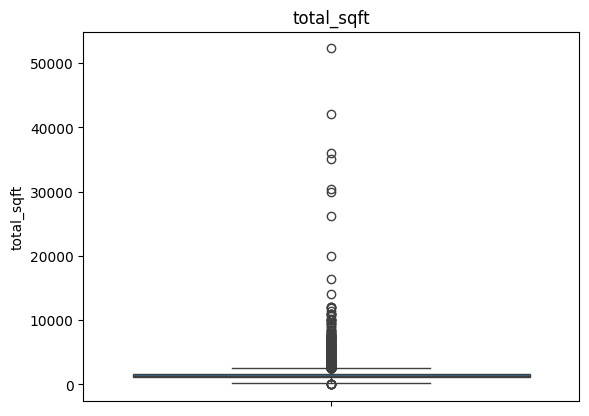

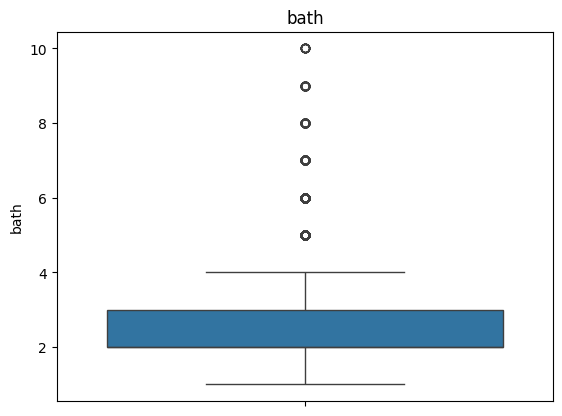

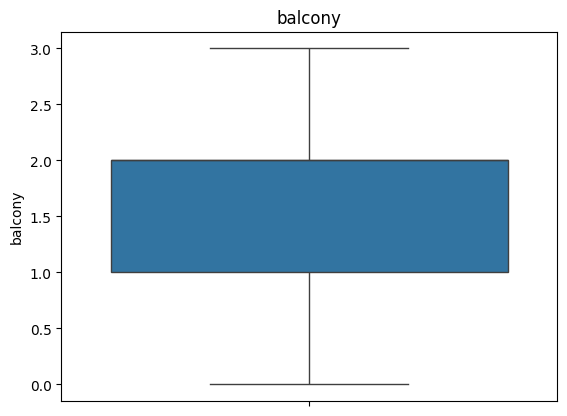

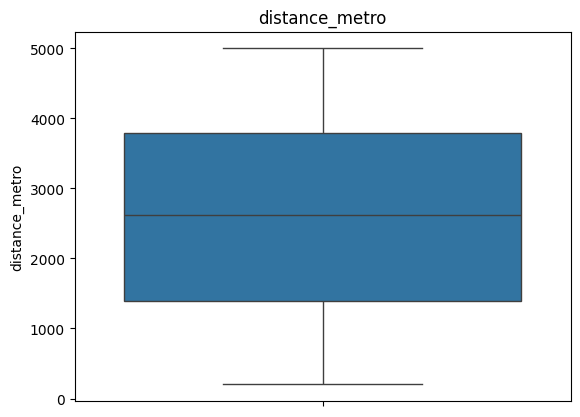

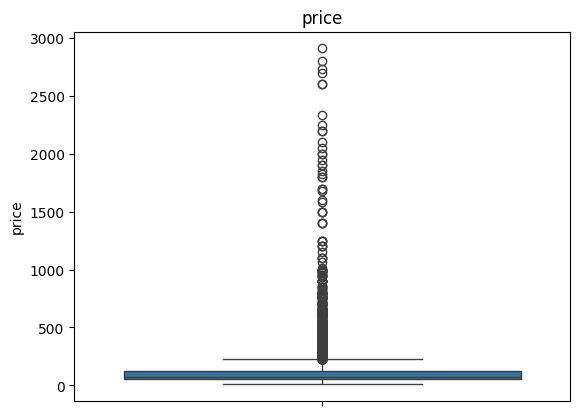

In [52]:
for col in ['total_sqft','bath','balcony','distance_metro','price']:
    plt.figure()
    sns.boxplot(y=data[col])
    plt.title(col)
    plt.show()

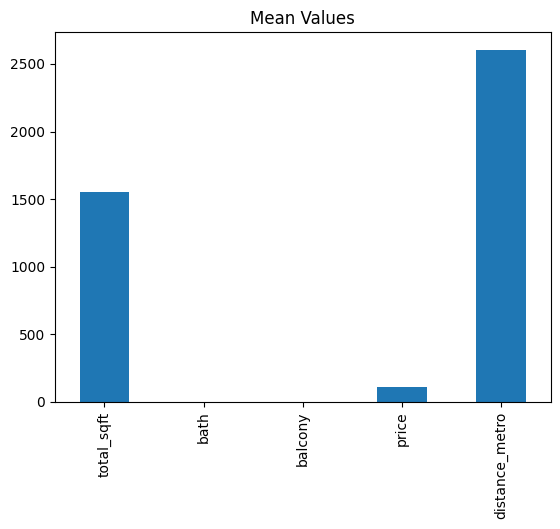

In [53]:
data.mean().plot(kind='bar')
plt.title("Mean Values")
plt.show()

In [54]:
X = data[['total_sqft','bath','balcony','distance_metro']]
y = data['price']

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [56]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [68]:
print("Feature Names:", ['total_sqft','bath','balcony','distance_metro'])
print("Coefficients:", model.coef_)

Feature Names: ['total_sqft', 'bath', 'balcony', 'distance_metro']
Coefficients: [28.75312183 36.46637631 -1.19508448  1.80637444]


In [57]:
print("R2 Score:", model.score(X_test, y_test))

R2 Score: 0.4262752925486182


In [63]:
avg_price = y.median()

In [69]:

sqft = float(input("Enter Square Footage: "))
bath = int(input("Enter Number of Bathrooms: "))
balcony = int(input("Enter Number of Balconies: "))
distance = float(input("Enter Distance to Metro (meters): "))

input_data = pd.DataFrame([[sqft, bath, balcony, distance]],columns=['total_sqft','bath','balcony','distance_metro'])

input_scaled = scaler.transform(input_data)

prediction = model.predict(input_scaled)[0]

print("Predicted Price (Lakhs):", round(prediction,2))
print("Predicted Price (Rupees):", round(prediction*100000))

if prediction < avg_price:
    print("Status: Affordable")
else:
    print("Status: Expensive")

Enter Square Footage: 2500
Enter Number of Bathrooms: 4
Enter Number of Balconies: 3
Enter Distance to Metro (meters): 800
Predicted Price (Lakhs): 203.99
Predicted Price (Rupees): 20399373
Status: Expensive
